In [ ]:
!pip install requests pillow

import requests
from PIL import Image
from io import BytesIO
import time


In [12]:
# Image Generator
def generate_image(prompt, reference_urls=None):
    headers = {"Authorization": API_KEY, "Content-Type": "application/json"}
    
    payload = {"prompt": prompt, "backendMode": 1}
    if reference_urls:
        payload["imageUrls"] = reference_urls
    
    response = requests.post(API_URL, headers=headers, json=payload)
    
    if response.status_code == 200:
        result = response.json()
        if 'result' in result and 'imageUrl' in result['result']:
            image_url = result['result']['imageUrl']
            img_response = requests.get(image_url)
            
            if img_response.status_code == 200:
                image = Image.open(BytesIO(img_response.content))
                filename = f"image_{int(time.time())}.png"
                image.save(filename)
                return image, image_url
    return None, None


# TEXT -> IMAGE # 

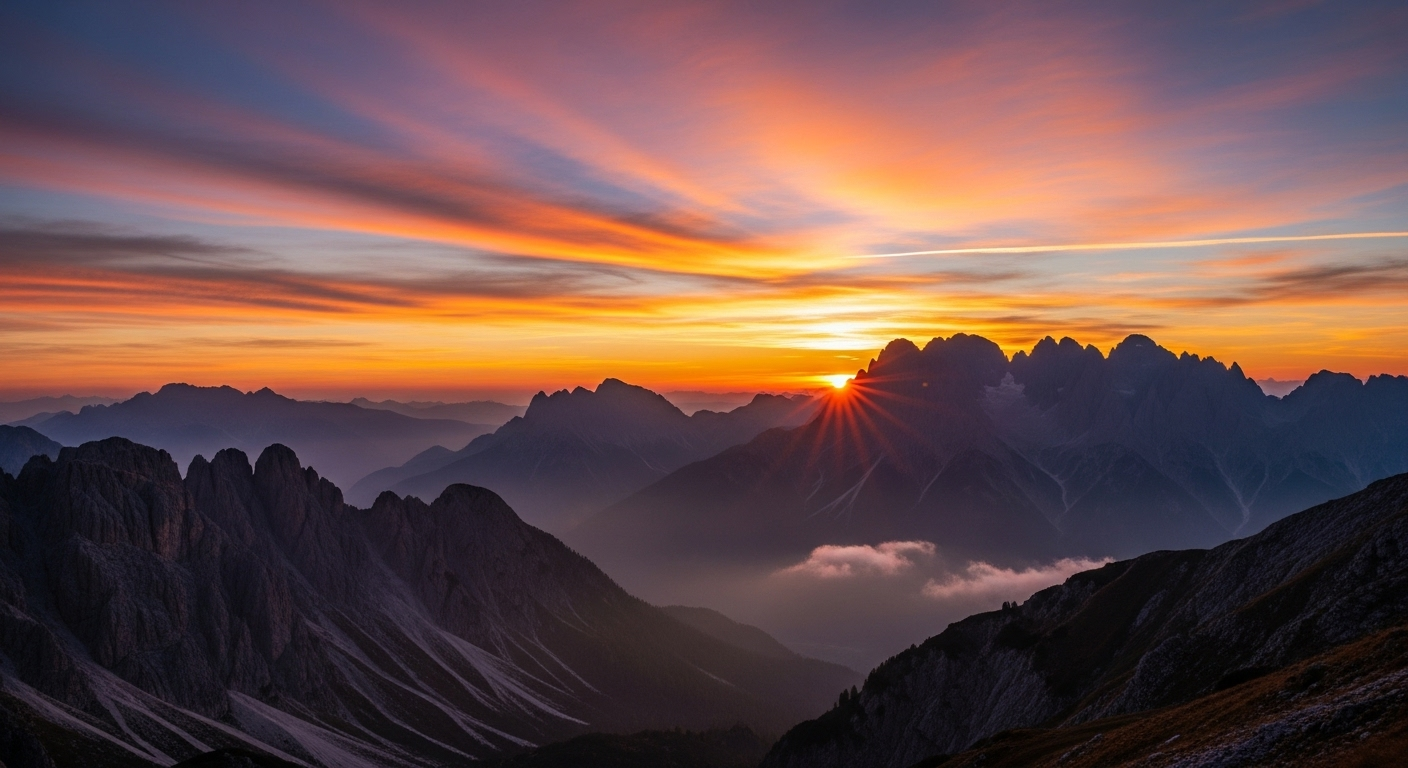

https://files.veoflow.cn/veo3_files/20251105/017885ab8f6a6bd362fcc03bff6e6f0f.png


In [2]:
prompt = "A beautiful sunset over mountains"  # Change this text
image, url = generate_image(prompt)
display(image)
print(url)

# IMAGE + TEXT -> IMAGE # 
## Conditioned by Image ## 

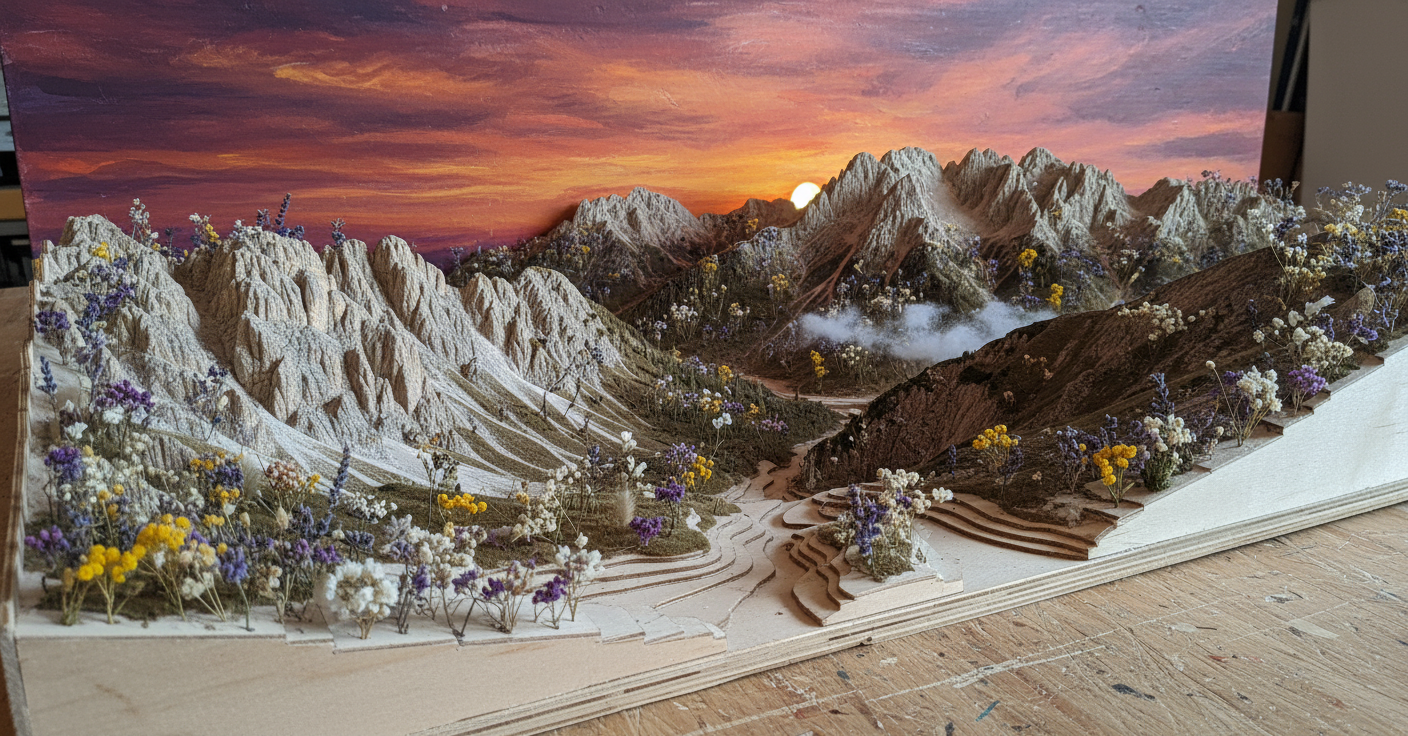

https://files.veoflow.cn/veo3_files/20251105/9a20e7aced325329b9f231d980e3f691.png


In [3]:
prompt = "Make it look like a Wooden handmade model style in architectural design, dried flowers used for trees"  # Change this text
image_2, url_2 = generate_image(prompt, [url])
display(image_2)
print(url_2)